# NBA Schedule Analysis

# Setup and Data    

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.colors import LinearSegmentedColormap
import calendar
import statsmodels.api as sm

# Note, you will likely have to change these paths. If your data is in the same folder as this project, 
# the paths will likely be fixed for you by deleting ../../Data/schedule_project/ from each string.
schedule = pd.read_csv("schedule.csv")
draft_schedule = pd.read_csv("schedule_24_partial.csv")
locations = pd.read_csv("locations.csv")
game_data = pd.read_csv("team_game_data.csv")

## Part 1 - Schedule Analysis               

### Question 1  

**QUESTION:** How many times are the Thunder scheduled to play 4 games in 6 nights in the 80-game draft of the 2024-25 season schedule? (Stretches can overlap)     

 

In [2]:
import pandas as pd
import numpy as np


def total_4_in_6(schedule, team):

    # Only include OKC games
    schedule = schedule[schedule["team"]== team].copy()  

    # By date just in case
    schedule["gamedate"] = pd.to_datetime(schedule["gamedate"], errors="coerce")
    schedule = schedule.sort_values("gamedate").reset_index(drop=True) 

    # For each Thunder game, count games in last 6 days
    schedule["games_in_last_6_days"] = schedule["gamedate"].apply(
        lambda x: schedule["gamedate"].between(x - pd.Timedelta(days=5), x).sum())

    # Look for all games where the value in "games_in_last_6_days" >= 4
    games = schedule.loc[schedule["games_in_last_6_days"] >= 4].reset_index(drop=True)

    total = int(len(games))

    ## Returns the total number
    return total, games

team = "OKC"
total, games = total_4_in_6(draft_schedule, team)
print(total, f"{team} games are the 4th game played over the past 6 nights")

26 OKC games are the 4th game played over the past 6 nights


### Question 2     

**QUESTION:** From 2014-15 to 2023-24, what is the average number of 4-in-6 stretches for a team in a season? Adjust each team/season to per-82 games before taking final average.   
  


In [3]:
# Compute per-82 adjusted 4-in-6 counts for every (team, season)
# inputs are the schedule, list of seasons to include (optional), list of teams to include (optional)
# Returns a DataFrame with: ['season','team','games_played','raw_4_in_6','adj_4_in_6']
# Returned df is grouped by seasons and teams
def team_season_4in6_per82(schedule, seasons=None, teams=None):
    
    df = schedule.copy()

    df['gamedate'] = pd.to_datetime(df['gamedate'])

    # filter out unwanted seasons/teams if any
    if seasons is not None:
        df = df[df['season'].isin(seasons)].copy()
    if teams is not None:
        df = df[df["team"].isin(teams)].copy()

    records = []
    
    for (season, team), group in df.groupby(["season", "team"], sort=False):
        
        games_played = len(group)
        if games_played == 0:
            continue

        # adjusted to a per-82-game basis
        raw_count, _ = total_4_in_6(group, team)
        adjusted_4_in_6 = (raw_count * 82) / games_played

        records.append({
            "season": season,
            "team": team,
            "games_played": games_played,
            "raw_4_in_6": raw_count,
            "adj_4_in_6": adjusted_4_in_6
        })

    return pd.DataFrame.from_records(records)

# Calculate the mean of per-82 adjusted 4-in-6 counts across all team–seasons
def league_avg_4in6_per82(team_season_df):
    
    return float(team_season_df["adj_4_in_6"].mean())

seasons = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

team_season_df = team_season_4in6_per82(schedule, seasons)
league_avg = league_avg_4in6_per82(team_season_df)
print("League average 4-in-6 per team-season (per 82):", round(league_avg, 1))

League average 4-in-6 per team-season (per 82): 25.1


### Question 3  

**QUESTION:** Which of the 30 NBA teams has had the highest average number of 4-in-6 stretches between 2014-15 and 2023-24? Which team has had the lowest average? Adjust each team/season to per-82 games.     


In [4]:
# Return a DataFrame with each team's average (per-82) across the provided seasons.
# Columns: ['team','avg_adj_4_in_6'], sorted desc.
def team_avg_4in6_per82(team_season_df):
    return (
        team_season_df
        .groupby("team", as_index=False)["adj_4_in_6"]
        .mean()
        .rename(columns={"adj_4_in_6": "avg_adj_4_in_6"})
        .sort_values("avg_adj_4_in_6", ascending=False, ignore_index=True)
    )

def team_extrema(team_avg_df):
    max_row = team_avg_df.iloc[0]
    min_row = team_avg_df.iloc[-1]
    return (max_row["team"], float(max_row["avg_adj_4_in_6"])), (min_row["team"], float(min_row["avg_adj_4_in_6"]))

seasons = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
team_season_df = team_season_4in6_per82(schedule, seasons)

# DataFrame with each team's average
team_avg_df = team_avg_4in6_per82(team_season_df)

output_table = (
    team_avg_df.set_index("team").T.rename(index={"avg_adj_4_in_6": "per82_avg"}))

display(output_table.style.format("{:.1f}"))

team_max, team_min = team_extrema(team_avg_df)

print("Highest avg (per-82):", (team_max[0], round(team_max[1], 1)))
print("Lowest  avg (per-82):", (team_min[0], round(team_min[1], 1)))

team,CHA,CHI,POR,DET,LAC,WAS,ATL,IND,OKC,MEM,UTA,CLE,MIN,SAS,GSW,SAC,BOS,PHI,TOR,HOU,MIL,ORL,DAL,LAL,MIA,BKN,DEN,PHX,NOP,NYK
per82_avg,28.1,28.0,26.9,26.5,26.5,26.4,26.3,26.3,26.1,26.0,25.8,25.7,25.6,25.6,25.3,25.2,25.2,25.2,24.8,24.6,24.3,24.3,23.7,23.7,23.6,23.3,22.9,22.6,22.5,22.2


Highest avg (per-82): ('CHA', 28.1)
Lowest  avg (per-82): ('NYK', 22.2)


### Question 4  

**QUESTION:** Is the difference between most and least from Q3 surprising, or do you expect that size difference is likely to be the result of chance?    

In [5]:
# Calculate the mean and std of all the adjusted team averages for 4_in_6s
mean_val = team_avg_df["avg_adj_4_in_6"].mean()
std_val  = team_avg_df["avg_adj_4_in_6"].std()

cha_val = team_avg_df.loc[team_avg_df["team"]=="CHA", "avg_adj_4_in_6"].iloc[0]
nyk_val = team_avg_df.loc[team_avg_df["team"]=="NYK", "avg_adj_4_in_6"].iloc[0]

z_cha = (cha_val - mean_val) / std_val
z_nyk = (nyk_val - mean_val) / std_val
gap   = cha_val - nyk_val
z_gap = gap / std_val

print(f"League mean: {mean_val:.1f}, std: {std_val:.1f}")
print(f"CHA: {cha_val:.1f} ({z_cha:.2f}σ above mean)")
print(f"NYK: {nyk_val:.1f} ({z_nyk:.2f}σ below mean)")
print(f"CHA–NYK gap: {gap:.1f} games (~{z_gap:.2f}σ)")

League mean: 25.1, std: 1.6
CHA: 28.1 (1.93σ above mean)
NYK: 22.2 (-1.87σ below mean)
CHA–NYK gap: 5.9 games (~3.80σ)


To determine whether the difference between the Hornets and Knicks average number of 4-in-6 stretches is within random bounds, we can compare each team’s value to the league distribution using the mean and standard deviation (z-score). Values within about +/- 2σ are generally considered normal variation,

The results show: 
- Both teams are nearly two (+1.93 and -1.87 respectively) standard deviations from the mean (25.1) in opposite directions
- The gap between them is almost four (3.8) standard deviations

The difference is likely can't only be attributed to random scheduling, but likely the result of structural factors such as geography, arena availability, or market-driven scheduling.

### Question 5   

**QUESTION:** What was BKN's defensive eFG% in the 2023-24 season? What was their defensive eFG% that season in situations where their opponent was on the second night of back-to-back?  

In [6]:
# Add a column to game_data indicating whether the OFFENSIVE team is on the second night of a back-to-back ('off_is_second_night_b2b')
def add_off_team_second_night_flag(game_data, gametype):

    g = game_data.copy()
    g["gamedate"] = pd.to_datetime(g["gamedate"], errors="coerce")

    # check to make sure we only use regular season games
    g = g[g["gametype"] == gametype].copy()

    off_dates = g[["off_team", "gamedate"]].dropna()
    off_dates["prev_date"] = off_dates["gamedate"] - pd.Timedelta(days=1)

    # Create (team, prev_date) key and check if that key exists in the (team, gamedate) table
    key_now = pd.MultiIndex.from_frame(off_dates[["off_team", "gamedate"]])
    key_previous = pd.MultiIndex.from_frame(off_dates[["off_team", "prev_date"]])

    # New list that says True/False depending on whether b2b or not 
    played_yesterday = key_previous.isin(key_now)

    g = g.copy()
    # add that list and a new column to 'game_data' called 'off_is_second_night_b2b'
    g["off_is_second_night_b2b"] = played_yesterday

    return g


# If opp_second_night is True, only includes games where the OFFENSIVE team was on the second night of a B2B.
# If False, excludes those games
# if None ignore B2B 
# Calculate defensive eFG% = (FGM + .5 x 3PM) / FGA for `team` in `season`.
def defensive_efg_percent(game_data, team, season, gametype=2, opp_second_night=None):
    
    # Add the off_is_second_night_b2b column
    g_flagged = add_off_team_second_night_flag(game_data, gametype=gametype)

    # Only include the season specified in the parameter
    season_str = str(season)
    season_mask = (
        g_flagged["season"].astype(str).eq(season_str)
        | g_flagged["season"].astype(str).str[:4].eq(season_str)
    )
    df = g_flagged.loc[
        (g_flagged["def_team"] == team)
        & season_mask
        & (g_flagged["gametype"] == gametype)
    ].copy()

    # Filter based on opp_second_night parameter
    if opp_second_night is True:
        df = df[df["off_is_second_night_b2b"]]
    elif opp_second_night is False:
        df = df[~df["off_is_second_night_b2b"]]

    # Aggregate opponent shooting against this defense
    fgm = df["fgmade"].sum(min_count=1)
    fg3 = df["fg3made"].sum(min_count=1)
    fga = df["fgattempted"].sum(min_count=1)

    if pd.isna(fga) or fga == 0:
        return np.nan

    # Calculate eFG%
    efg = (fgm + 0.5 * fg3) / fga
    return float(efg)

## Summary function that returns a dictionary with overall, on-b2b, and off-b2b defensive eFG%
def defensive_efg_summary(game_data, team, season, gametype):
    
    # Add the off_is_second_night_b2b column
    g_flagged = add_off_team_second_night_flag(game_data, gametype=gametype)

    # Only include the season specified in the parameter
    season_str = str(season)
    season_mask = (g_flagged["season"].astype(str).eq(season_str))
    df = g_flagged.loc[
        (g_flagged["def_team"] == team) &
        season_mask &
        (g_flagged["gametype"] == gametype)
    ].copy()

    # Calculate overall, on-b2b, and off-b2b defensive eFG%
    overall = defensive_efg_percent(game_data, team, season, gametype=gametype, opp_second_night=None)
    on_b2b  = defensive_efg_percent(game_data, team, season, gametype=gametype, opp_second_night=True)
    off_b2b = defensive_efg_percent(game_data, team, season, gametype=gametype, opp_second_night=False)

    return {
            "team": team,
            "season": str(season),
            "overall_def_efg": overall,
            "opp_b2b_def_efg": on_b2b,
            "non_b2b_def_efg": off_b2b,
            "n_games_overall": int(len(df)),
            "n_games_b2b": int((df["off_is_second_night_b2b"]).sum()),
            "n_games_non_b2b": int((~df["off_is_second_night_b2b"]).sum()),
        }

# Create a styled summary table for defensive eFG%
def defensive_efg_summary_table(game_data, team, season, gametype=2, decimals=1):

    # Get the summary dictionary
    s = defensive_efg_summary(game_data, team=team, season=season, gametype=gametype)

    rows = [
        {
            "Split": "Overall",  # col1
            "Def eFG%": s["overall_def_efg"], # col2
            "Games": s["n_games_overall"], # col3
        },
        {
            "Split": "Opp 2nd Night B2B", # col1
            "Def eFG%": s["opp_b2b_def_efg"], # col2
            "Games": s["n_games_b2b"], # col3
        },
        {
            "Split": "Non-B2B", # col1
            "Def eFG%": s["non_b2b_def_efg"], # col2
            "Games": s["n_games_non_b2b"], # col3
        },
    ]

    df = pd.DataFrame(rows)

    # percentage formatting + light color gradient
    styled = (
        df.style
          .format({"Def eFG%": f"{{:.{decimals}%}}", "Games": "{:d}"})
          .hide(axis="index")
          .set_caption(f"Defensive eFG% — {team} {season}, Gametype {gametype}")
          .background_gradient(subset=["Def eFG%"], cmap="RdYlGn_r")  # green better (lower eFG%)
          .set_properties(subset=["Split"], **{"font-weight": "600"})
    )
    return styled, df

# Styled table
styled, df_efg = defensive_efg_summary_table(game_data, team="BKN", season="2023", gametype=2)
display(styled)

Split,Def eFG%,Games
Overall,54.3%,82
Opp 2nd Night B2B,53.5%,16
Non-B2B,54.6%,66


- BKN Defensive eFG%: 54.3%   
- When opponent on a B2B: 53.5%    

## Part 2 - Trends and Visualizations                   

### Question 6   

**QUESTION:** Identify at least 2 trends in scheduling over time. How are the more recent schedules different from the schedules of the past? Include a visual highlighting or explaining each trend


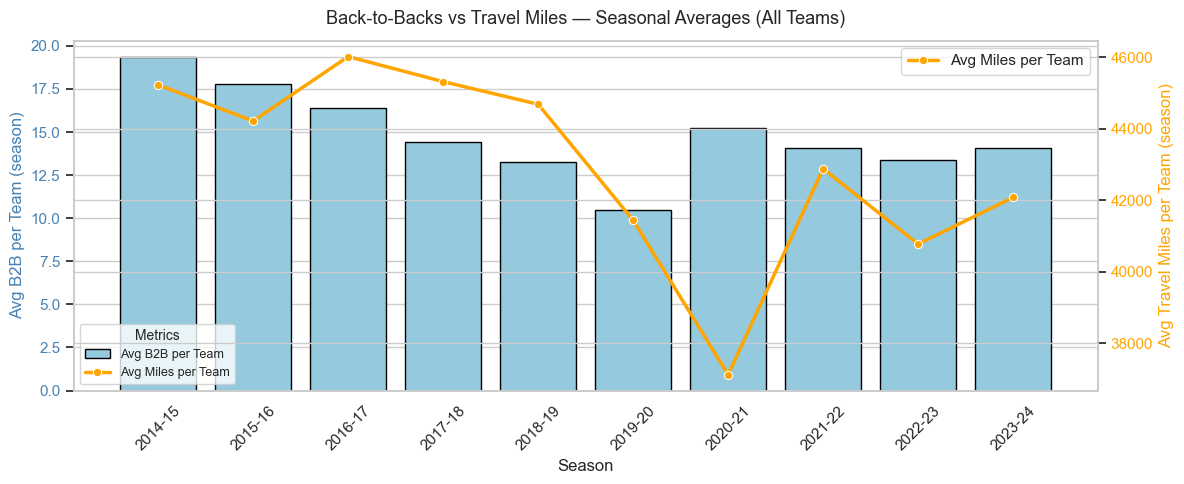

In [7]:
# Great-circle distance in miles
def _haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.7613  # Earth radius in miles
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def _make_season_label(start_year: int) -> str:
    """Convert start year -> 'YYYY-YY', e.g., 2013 -> '2013-14'."""
    end_two = str((start_year + 1) % 100).zfill(2)
    return f"{start_year}-{end_two}"

# For each game row (team perspective), attach the venue location:
# - If home==1: use the 'team' home location
# - If home==0: use the 'opponent' home location
def _add_game_coords(schedule: pd.DataFrame, locations: pd.DataFrame) -> pd.DataFrame:
   
    df = schedule.copy()
    df["gamedate"] = pd.to_datetime(df["gamedate"], errors="coerce")
    df["team"] = df["team"].astype(str)
    df["opponent"] = df["opponent"].astype(str)

    loc = locations.rename(columns={"team": "_team"}).copy()
    loc["_team"] = loc["_team"].astype(str)

    # Merge for team home coords
    df = df.merge(
        loc.rename(columns={
            "_team": "team",
            "latitude": "team_lat",
            "longitude": "team_lon",
            "timezone": "team_tz"
        }),
        on="team", how="left"
    )

    # Merge for opponent home coords
    df = df.merge(
        loc.rename(columns={
            "_team": "opponent",
            "latitude": "opp_lat",
            "longitude": "opp_lon",
            "timezone": "opp_tz"
        }),
        on="opponent", how="left"
    )

    # Choose venue coords based on home/away
    home_flag = df["home"].astype(int)
    df["venue_lat"] = np.where(home_flag == 1, df["team_lat"], df["opp_lat"])
    df["venue_lon"] = np.where(home_flag == 1, df["team_lon"], df["opp_lon"])

    # Seperate season label (e.g. 2013-14) and season as int (e.g. 2013)
    df["season"] = df["season"].astype(int)
    df["season_label"] = df["season"].apply(_make_season_label)

    return df

# For each (team, season):
# - is_b2b_second: True if previous game was 1 day before
# - miles_since_prev: miles from previous venue (calculated with haversine())
# Returns per-game rows: ['team','season','season_label','gamedate','is_b2b_second','miles_since_prev']
def _compute_team_game_features(sched_with_coords: pd.DataFrame) -> pd.DataFrame:

    # sort and group by (team, season)
    df = sched_with_coords.copy().sort_values(["team", "season", "gamedate"])
    gb = df.groupby(["team", "season"], group_keys=False)

    # previous game date and venue
    df["prev_gamedate"] = gb["gamedate"].shift(1)
    df["prev_lat"] = gb["venue_lat"].shift(1)
    df["prev_lon"] = gb["venue_lon"].shift(1)

    # is_b2b_second: previous game was exactly 1 day before
    day_diff = (df["gamedate"] - df["prev_gamedate"]).dt.days
    df["is_b2b_second"] = (day_diff == 1)

    # miles_since_prev: haversine distance from previous venue (0 if no previous game or same venue)
    df["miles_since_prev"] = np.where(
        df["prev_lat"].notna(),
        _haversine_miles(df["prev_lat"], df["prev_lon"], df["venue_lat"], df["venue_lon"]),
        0.0
    )

    return df[["team", "season", "season_label", "gamedate", "is_b2b_second", "miles_since_prev"]]

# Returns a per-season table with:
# - avg_b2b_per_team: average # of second-night B2B games per team in that season
# - avg_miles_per_team: average total travel miles per team in that season
# - n_teams: number of teams included in that season's average
def build_seasonal_b2b_and_miles(schedule, locations, seasons = None, teams = None):
    
    sched = schedule.copy()
    sched["gamedate"] = pd.to_datetime(sched["gamedate"], errors="coerce")
    sched["season"] = sched["season"].astype(int)

    # filter out unwanted seasons/teams if any
    if seasons is not None:
        seasons = {int(str(s)[:4]) for s in seasons}  # accept "2014-15" or 2014
        sched = sched[sched["season"].isin(seasons)].copy()
    if teams is not None:
        sched = sched[sched["team"].isin(teams)].copy()

    # attach venue coordinates and season_label
    schedc = _add_game_coords(sched, locations)

    # compute per-game features per (team, season)
    tdf = _compute_team_game_features(schedc)

    # group and aggregate to per-team per-season
    per_team_season = (
        tdf.groupby(["team", "season", "season_label"], as_index=False)
           .agg(b2b_games=("is_b2b_second", "sum"),
                miles=("miles_since_prev", "sum"))
    )

    # average across teams per season
    season_df = (
        per_team_season.groupby(["season", "season_label"], as_index=False)
                       .agg(avg_b2b_per_team=("b2b_games", "mean"),
                            avg_miles_per_team=("miles", "mean"),
                            n_teams=("team", "nunique"))
                       .sort_values("season")
    )

    return season_df

def plot_season_b2b_vs_miles(season_df):

    df = season_df.sort_values("season").copy()

    sns.set_theme(style="whitegrid")
    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Bars: Avg B2B per team (left y-axis)
    bar = sns.barplot(
        data=df, x="season_label", y="avg_b2b_per_team",
        color="skyblue", edgecolor="black", ax=ax1, label="Avg B2B per Team"
    )
    ax1.set_ylabel("Avg B2B per Team (season)", color="steelblue")
    ax1.set_xlabel("Season")
    ax1.tick_params(axis="x", rotation=45)
    ax1.tick_params(axis="y", labelcolor="steelblue")

    # Line: Avg miles per team (right y-axis)
    ax2 = ax1.twinx()
    line = sns.lineplot(
        data=df, x="season_label", y="avg_miles_per_team",
        color="orange", marker="o", linewidth=2.5, ax=ax2, label="Avg Miles per Team"
    )
    ax2.set_ylabel("Avg Travel Miles per Team (season)", color="orange")
    ax2.tick_params(axis="y", labelcolor="orange")

    lines, labels = [], []
    for ax in [ax1, ax2]:
        line_objs, label_objs = ax.get_legend_handles_labels()
        lines += line_objs
        labels += label_objs

    ax1.legend(
        lines, labels,
        loc="lower left",
        frameon=True,
        title="Metrics",
        fontsize=9,
        title_fontsize=10
    )

    plt.title("Back-to-Backs vs Travel Miles — Seasonal Averages (All Teams)", fontsize=13, pad=12)
    plt.tight_layout()
    plt.show()

# Build monthly series across all seasons in the dataset
season_df = build_seasonal_b2b_and_miles(schedule, locations)

plot_season_b2b_vs_miles(season_df)



The results show a clear decline in both Average Miles per Team as well as Average Back to Backs in games from 2014 to 2024.
- Back to Backs dropped from nearly 20 in 2016-17 to roughly 13 in recent seasons
- Miles traveled dropped from nearly 46,000 in 2016-17 to roughly 42,000 in recent seasons

It may be important to note that the 2020–21 pandemic-shortened season saw a sharp dip in travel distances

### Question 7    

**QUESTION:** Design a plotting tool to help visualize a team’s schedule for a season. The plot should cover the whole season and should help the viewer contextualize and understand a team’s schedule, potentially highlighting periods of excessive travel, dense blocks of games, or other schedule anomalies. Plot OKC and DEN's provided 80-game 2024-25 schedules.   

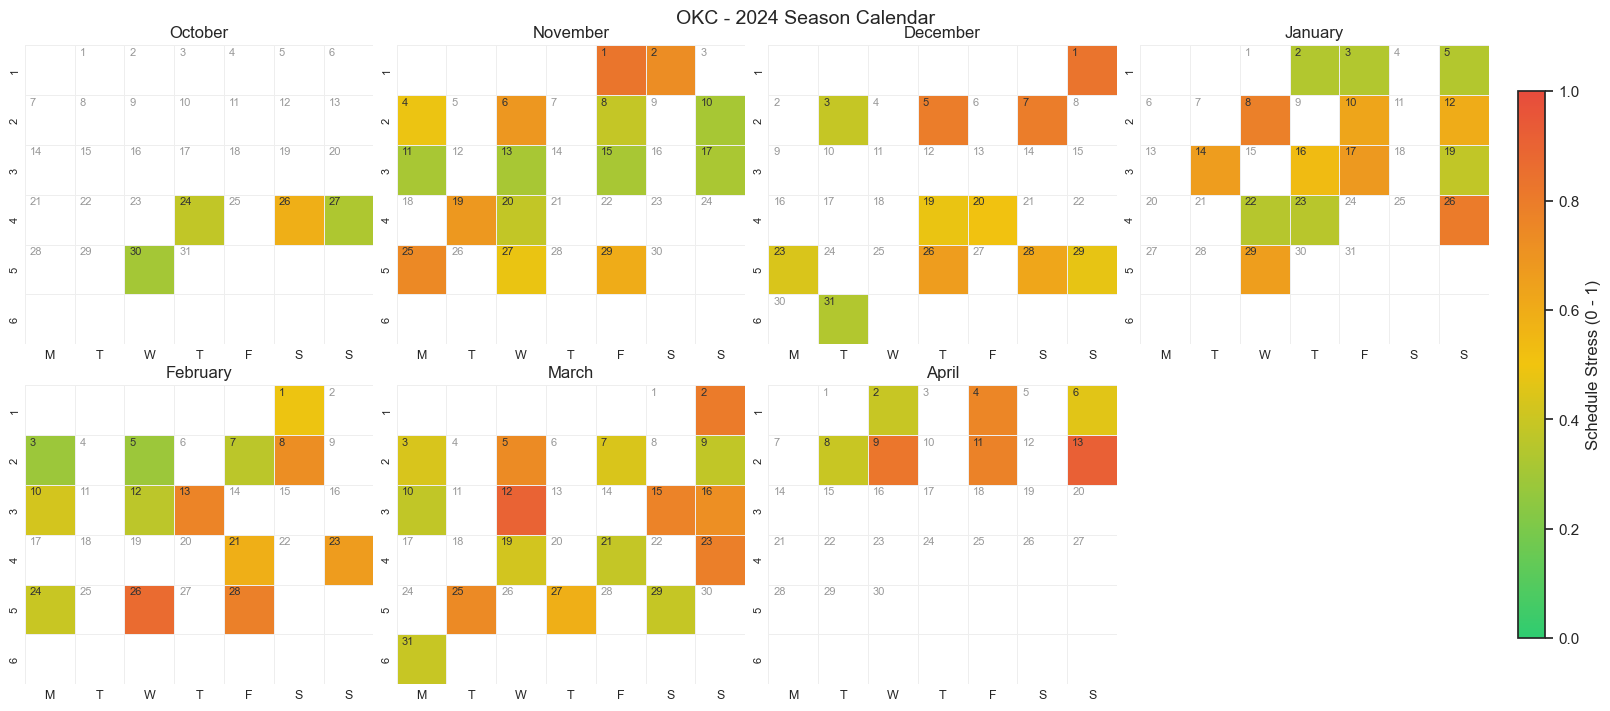

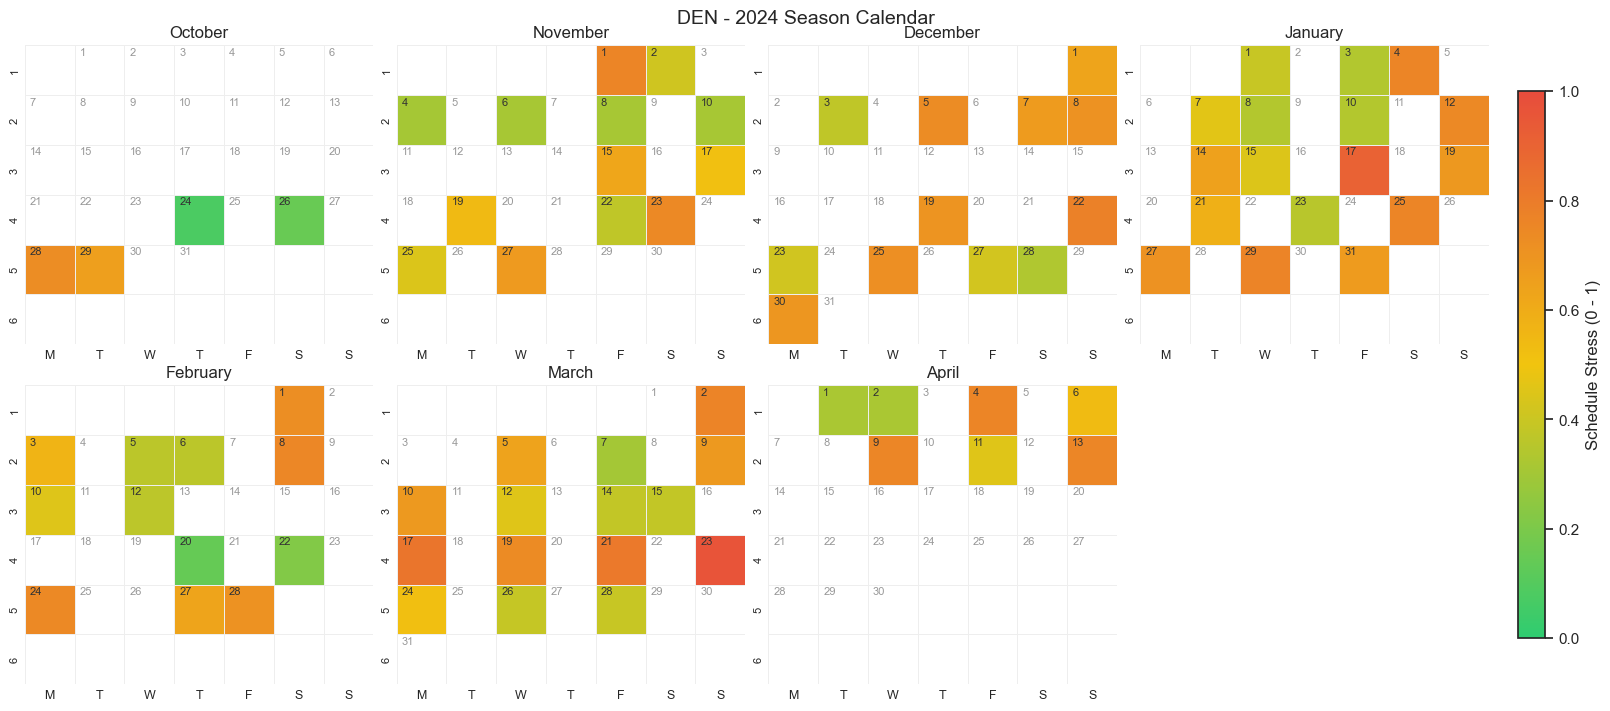

In [8]:
# Attach venue (lat,lon) for each schedule row (team perspective)
def _add_venue_coordinates(schedule, locations):
    
    df = schedule.copy()

    df["gamedate"] = pd.to_datetime(df["gamedate"], errors="coerce")
    df["team"] = df["team"].astype(str)
    df["opponent"] = df["opponent"].astype(str)

    loc = locations.rename(columns={"team": "_team"}).copy()
    loc["_team"] = loc["_team"].astype(str)

    df = df.merge(
        loc.rename(columns = {"_team":"team", "latitude":"team_lat", "longitude":"team_lon", "timezone":"team_tz"}),
        on = "team", how = "left"
    )

    df = df.merge(
        loc.rename(columns={"_team":"opponent", "latitude":"opp_lat", "longitude":"opp_lon", "timezone":"opp_tz"}),
        on="opponent", how="left"
    )

    home_flag = df["home"].astype(int)
    df["venue_lat"] = np.where(home_flag == 1, df["team_lat"], df["opp_lat"])
    df["venue_lon"] = np.where(home_flag == 1, df["team_lon"], df["opp_lon"])
    return df


# For each date d in a sorted date series, count how many dates fall in [d-k, d]
# Returns a series aligned to the original order.
def _games_last_k_days(dates_series, k: int = 6):

    ds = pd.to_datetime(dates_series).reset_index(drop=True)
    out = np.empty(len(ds), dtype=int)
    left=0
    for i, d in enumerate(ds):
        # move left pointer while outside the window
        window_start = d - pd.Timedelta(days=k)
        while left < i and ds[left] < window_start:
            left += 1
        out[i] = i - left + 1  # inclusive of i
    return pd.Series(out, index=dates_series.index)


# Will return a per-game df for the given (team, season) with:
# [gamedate, opponent, home, miles_since_prev, games_last_6, 'is_b2b_second','season_progress']
def build_team_season_features(schedule, locations, team, season):
    
    df = schedule.copy()
    df["gamedate"] = pd.to_datetime(df["gamedate"], errors='coerce')

    df = df[df['team'] == team].copy()
    df = df[df['season'] == season].copy()

    if df.empty:
        return df.assign(
            miles_since_prev=np.nan, games_last_6=np.nan,
            is_b2b_second=False, season_progress=np.nan
        )

    # This function was defined earlier
    # add venue coordinates column to df
    df = _add_venue_coordinates(df, locations)

    df = df.sort_values("gamedate").reset_index(drop=True)

    # count travel miles since previous game
    df["prev_lat"] = df["venue_lat"].shift(1)
    df["prev_lon"] = df["venue_lon"].shift(1)
    df["miles_since_prev"] = np.where(
        df["prev_lat"].notna(),
        _haversine_miles(df["prev_lat"], df["prev_lon"], df["venue_lat"], df["venue_lon"]),
        0.0
    )

    # games in the last 6 days 
    df["games_last_6"] = _games_last_k_days(df["gamedate"], k=6)

    # second night of B2B flag
    df["days_since_prev"] = (df["gamedate"] - df["gamedate"].shift(1)).dt.days
    df["is_b2b_second"] = df["days_since_prev"] == 1

    # season progression
    n = len(df)
    df["season_progress"] = np.linspace(0.0, 1.0, num=n)

    # return a dataframe with the columns below
    return df[["gamedate","opponent","home","miles_since_prev","games_last_6","is_b2b_second","season_progress"]]

# Min-max normalize with clipping to [0,1]
def _normalize_clip(x, min_v, max_v):
    return np.clip((x - min_v) / (max_v - min_v), 0.0, 1.0) if max_v > min_v else np.zeros_like(x, dtype=float)

# Add 'stress', in [0,1], combining:
# - distance (30%)
# - games_last_6 (30%)
# - home/away (30%)
# - season progress (10%)
#  
def compute_stress_score(games_df, weights = None):

    df = games_df.copy()

    # set the following weights if they weren't passed through the parameter
    if weights is None:
        weights = {'distance': 0.30, 'density': 0.30, 'homeaway': 0.30, 'progress': 0.10}

    # make sure outliers don't have too big of an effect - Normalizations
    distance_cap = 2000.0
    df['dist_norm'] = _normalize_clip(df["miles_since_prev"].astype(float).to_numpy(), 0.0, distance_cap)
    # density: cap at 4 (4-in-6 tail)
    df["density_norm"] = _normalize_clip(df["games_last_6"].astype(float).to_numpy(), 0.0, 4.0)
    # home/away: home easier, away harder
    df["homeaway_norm"] = np.where(df["home"].astype(int) == 1, 0.0, 1.0)
    # season_progress already 0.-.1
    df["progress_norm"] = df["season_progress"].astype(float)

    # Weighted Sum = normalized stress
    df["stress"] = (
        weights["distance"] * df["dist_norm"] +
        weights["density"]  * df["density_norm"] +
        weights["homeaway"] * df["homeaway_norm"] +
        weights["progress"] * df["progress_norm"]
    )

    # helpful flags
    df["is_4_in_6_tail"] = df["games_last_6"] >= 4

    return df

# Builds a calendar grid for one (team, season) 
# Returns:
# - heat_df  (rows = weeks, cols = Mon through Sun, value = stress number)
# - hover_df 
# - date_df  
def build_calendar_matrix(stress_df, week_start = "Mon", fill_value = 0.0):

    if stress_df.empty:
        # Build a 1x7 empty grid fallback
        cols = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
        heat_df  = pd.DataFrame([ [np.nan]*7 ], columns=cols)
        hover_df = pd.DataFrame([ ["No data"]*7 ], columns=cols)
        date_df  = pd.DataFrame([ [pd.NaT]*7 ], columns=cols)
        return heat_df, hover_df, date_df

    df = stress_df.copy()
    df["date"] = pd.to_datetime(df["gamedate"]).dt.normalize()

    start_date = df["date"].min()
    end_date = df["date"].max()

    # start week with monday or sunday
    if week_start.lower().startswith("mon"):
        start_week = start_date - pd.Timedelta(days=start_date.weekday())  # Monday=0
    else:  # Sunday start
        start_week = start_date - pd.Timedelta(days=(start_date.weekday()+1) % 7)

    end_pad = 6 - (end_date - start_week). days % 7
    full_end = end_date + pd.Timedelta(days=end_pad)

    full_days = pd.date_range(start_week, full_end, freq="D")

    # map weekday names
    dow_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
    if not week_start.lower().startswith("mon"):
        dow_names = ["Sun","Mon","Tue","Wed","Thu","Fri","Sat"]

    # create empty grids
    n_weeks = int(len(full_days) / 7)
    heat_grid = np.full((n_weeks, 7), fill_value, dtype=float)
    hover_grid = np.full((n_weeks, 7), "", dtype=object)
    date_grid  = np.empty((n_weeks, 7), dtype="datetime64[ns]")
    date_grid[:] = np.datetime64("NaT")

    # index df by date for quick lookup (games per date)
    games_by_date = df.groupby("date").agg({
        "opponent": lambda x: list(x),
        "home": "sum",
        "miles_since_prev": "sum",
        "games_last_6": "max",
        "is_b2b_second": "sum",
        "is_4_in_6_tail": "sum",
        "stress": "mean"  # if multiple games same day, take mean stress
    }).reset_index()

    # this 
    games_by_date["home_text"] = games_by_date["home"].apply(lambda h: "Home" if h > 0 else "Away")
    games_by_date["opp_text"] = games_by_date["opponent"].apply(
        lambda lst: " /".join([str(o) for o in lst]) if isinstance(lst, list) else str(lst)
    )

    # Fill in the grids
    for i, d in enumerate(full_days):
        week_idx = i // 7
        col_idx = i % 7

        date_grid[week_idx, col_idx] = d

        row = games_by_date[games_by_date["date"] == d]
        if len(row) == 0:
            # off day
            heat_grid[week_idx, col_idx]  = fill_value
            hover_grid[week_idx, col_idx] = f"{d.date()}<br>No game"
        else:
            r = row.iloc[0]
            # heat = stress
            heat_grid[week_idx, col_idx] = float(r["stress"])

            hover_grid[week_idx, col_idx] = (
                f"{d.date()}<br>"
                f"{r['home_text']} vs {r['opp_text']}<br>"
                f"Stress: {r['stress']:.2f}<br>"
                f"Games last 6: {int(r['games_last_6'])}<br>"
                f"2nd night B2B: {int(r['is_b2b_second'])>0}<br>"
                f"4-in-6 tail: {int(r['is_4_in_6_tail'])>0}<br>"
                f"Miles since prev: {r['miles_since_prev']:.0f}"
            )

    heat_df  = pd.DataFrame(heat_grid, columns=dow_names)
    hover_df = pd.DataFrame(hover_grid, columns=dow_names)
    date_df  = pd.DataFrame(date_grid, columns=dow_names)

    # label rows as "Week of YYYY-MM-DD"
    week_labels = [f"Week of {full_days[i*7].date()}" for i in range(n_weeks)]
    heat_df.index  = week_labels
    hover_df.index = week_labels
    date_df.index  = week_labels

    return heat_df, hover_df, date_df
            
# Calculate the per-game features for a (team, season)
# calculates the composite stress (color on calendar)
# Builds the calendar matrix
# Renders the plotly heatmap
# Returns fig, heat_df, raw_games_df

def _month_iter(start_date: pd.Timestamp, end_date: pd.Timestamp):
    """Yield (year, month) pairs from start..end inclusive."""
    y, m = start_date.year, start_date.month
    while (y < end_date.year) or (y == end_date.year and m <= end_date.month):
        yield y, m
        m += 1
        if m == 13:
            m = 1
            y += 1


# Month-by-month calendar heatmap 
# Weeks are rows, Mon–Sun are columns.
# Colors show your composite 'stress' (0–1). One subplot per month that appears in the season.
def plot_team_calendar_months(schedule, locations, team, season,
                              week_start="Mon", weights=None,
                              title=None, cmap=None):

    # Build per-game features + stress
    games = build_team_season_features(schedule, locations, team, season)
    if games.empty:
        raise ValueError(f"No games found for team={team}, season={season}")
    games = compute_stress_score(games, weights=weights)

    # map date to stress (midnight dates)
    games["date"] = pd.to_datetime(games["gamedate"]).dt.normalize()
    stress_by_date = games.set_index("date")["stress"].to_dict()

    # Figure date range: min to max in this season
    start_date = games["date"].min().replace(day=1)
    # last day in last month with a game
    last = games["date"].max()
    end_date = (last.replace(day=1) + pd.offsets.MonthEnd(0))

    # Calendar engine & weekday order
    firstweekday = 0 if week_start.lower().startswith("mon") else 6  # 0=Mon, 6=Sun
    cal = calendar.Calendar(firstweekday=firstweekday)
    if firstweekday == 0:
        dow = ["M","T","W","T","F","S","S"]
    else:
        dow = ["S","M","T","W","T","F","S"]

    # Colormap (green to red)
    if cmap is None:
        cmap = LinearSegmentedColormap.from_list("stress_g2r", ["#2ECC71", "#F1C40F", "#E74C3C"])

    # Build list of months present
    months = list(_month_iter(start_date, end_date))
    n_months = len(months)

    # grid: up to 12 months: 3 rows x 4 cols
    ncols = 4
    nrows = int(np.ceil(n_months / ncols))

    sns.set_theme(style="white")
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.4*nrows), constrained_layout=True)
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = axes[:, None]

    # Draw each month
    vmin, vmax = 0.0, 1.0
    # collect a mappable for a single shared colorbar
    mappable = None

    for idx, (year, month) in enumerate(months):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]

        # weeks: list of lists (zero = pad)
        weeks = cal.monthdayscalendar(year, month)  # rows=weeks, cols=days
        if len(weeks) < 6:
            # Pad to 6 weeks for consistent layout
            weeks += [[0]*7] * (6 - len(weeks))

        # Build stress matrix (NaN where no day)
        mat = np.full((len(weeks), 7), np.nan, dtype=float)
        for i, wk in enumerate(weeks):
            for j, d in enumerate(wk):
                if d > 0:
                    date = pd.Timestamp(year=year, month=month, day=d)
                    mat[i, j] = stress_by_date.get(date, np.nan)

        # Heatmap for this month
        hm = sns.heatmap(mat, vmin=vmin, vmax=vmax, cmap=cmap,
                         cbar=False, square=True, linewidths=0.5, linecolor="#eee",
                         ax=ax)

        # Remember a mappable for colorbar
        if mappable is None:
            mappable = hm.collections[0]

        # Style: title, ticks, weekday labels
        month_name = calendar.month_name[month]
        ax.set_title(month_name, fontsize=12, pad=6)
        ax.set_xticks(np.arange(0.5, 7.5, 1))
        ax.set_xticklabels(dow, fontsize=9)
        ax.set_yticks(np.arange(0.5, len(weeks)+0.5, 1))
        ax.set_yticklabels([str(i+1) for i in range(len(weeks))], fontsize=8)
        ax.tick_params(length=0)

        # Annotate day numbers, faded if no stress value)
        for i, wk in enumerate(weeks):
            for j, d in enumerate(wk):
                if d > 0:
                    val = mat[i, j]
                    color = "#333333" if not np.isnan(val) else "#999999"
                    ax.text(j+0.1, i+0.2, str(d), fontsize=8, color=color)

    # Hide unused subplots 
    for k in range(n_months, nrows*ncols):
        r, c = divmod(k, ncols)
        axes[r, c].axis("off")

    # Shared title + colorbar
    if title is None:
        title = f"{team} - {season} Season Calendar"
    fig.suptitle(title, fontsize=14, y=1.02)

    # Single shared colorbar
    cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(), shrink=0.85, pad=0.02)
    cbar.set_label("Schedule Stress (0 - 1)")

    plt.show()
    return fig, games

# OKC 2024
fig_okc, games_okc = plot_team_calendar_months(draft_schedule, locations, team="OKC", season=2024, week_start="Mon")

fig_den, games_den = plot_team_calendar_months(draft_schedule, locations, team="DEN", season=2024, week_start="Mon")

### Question 8    

**QUESTION:** What is the best and worst part of OKC’s 2024-25 draft schedule? 

In [9]:
# Summarize average stress per week for a given team and season.
def summarize_weekly_stress(games_df, team, season):

    df = games_df.copy()
    df["date"] = pd.to_datetime(df["gamedate"])
    df["week_start"] = df["date"] - pd.to_timedelta(df["date"].dt.weekday, unit='D')  # Monday as week start
    weekly = (df.groupby("week_start", as_index=False)
                .agg(avg_stress=("stress", "mean"),
                     games=("gamedate", "count")))

    # Format for display
    weekly["week_label"] = weekly["week_start"].dt.strftime("Week of %b %d")
    weekly["avg_stress"] = weekly["avg_stress"].round(2)

    # Display table
    display(weekly[["week_label", "avg_stress", "games"]]
        .rename(columns={"week_label":"Week", "avg_stress":"Avg Stress", "games":"Games"}))

weekly_okc = summarize_weekly_stress(games_okc, team="OKC", season=2024)



,Week,Avg Stress,Games
0,Week of Oct 21,0.43,3
1,Week of Oct 28,0.62,3
2,Week of Nov 04,0.47,4
3,Week of Nov 11,0.31,4
4,Week of Nov 18,0.53,2
5,Week of Nov 25,0.66,4
6,Week of Dec 02,0.66,3
7,Week of Dec 16,0.50,2
8,Week of Dec 23,0.55,4
9,Week of Dec 30,0.34,4



The schedule-stress model combines travel distance, schedule density, back-to-backs, and home/away balance into a single “stress” metric that ranges from 0-1. The attached month-by-month calendar shows this distribution across the 2024-25 season, where green denotes low schedule pressure and red indicates high stress.

**Best stretch**: Mid-November (Week of Nov 11, Avg Stress = 0.31) and early December (Week of Dec 30, Avg Stress = 0.34). Both of these periods happen to combine balanced home games with travel gaps longer than two days between games. These weeks may be ideal for experimenting with player rotations or fine-tuning individual skills

**Worst stretch**: Late February (Week of Feb 24, Avg Stress = 0.71) and early April (Week of Apr 07, Avg Stress = 0.73). Both of these periods have 4-in-6-day clusters and multi-city road trips, including back-to-back sets. Prepare for more recovery needs during these weeks as well as potential load management rotations.

It may be important to note that from January 6 to March 10, stress remains consistently above 0.55 for nine straight weeks, the longest high-load window of the season. This is partially due to the season progression stress factor I've incorporated. It may be wise to prioritize practice intensity tapering around March, allowing full readiness entering the playoff push

**Summary**

OKC’s schedule starts light, ramps up sharply after New Year, and peaks just before April. Strategic rest and rotation planning during the February-March window will be crucial to maintain performance and minimize injury risk heading into postseason play.

## Part 3 -- Modeling     

### Question 9   

**QUESTION:** Estimate how many more/fewer regular season wins each team has had due to schedule-related factors from 2019-20 though 2023-24. Final answer should have one number for each team, representing the total number of wins (not per 82, and not a per-season average). Consider the on-court strength of the scheduled opponents as well as the impact of travel/schedule density. Include the teams and estimates for the most helped and most hurt 

### Explanation

To quantify how much schedule-related factors affect the impact the wins, seperate from opponent quality, I fit a logistic regression at the team-game level for games spanning from the 2019-20 season to 2023-24 season. The dependent variable was win (1 or 0).

Predictors were take from earlier functions. Specifically: 
- is_home (home or away game)
- is_b2b (is a game the second game of a back to back)
- games_last_6 (to further represent density of games)
- travel_miles (distance since prior game)
- season_progress (wear as the season progresses) 

Opponent strength measured as the opponent’s season average point differential per game as opposed to than raw win percentage. I thought that this would give the model more insight.

- compute_team_season_point_differential() aggregates team_game_data by nbagameid to get each team’s points for vs points against, computes per-game point differential, then averages by (season,team) to produce avg_point_differential
- build_features_all_teams() loops every (team,season) and reuses build_team_season_features() (built earlier) to get one row per game with gamedate, opponent, home, miles_since_prev, games_last_6, is_b2b_second, season_progress
- build_regression_dataset() merges those features with the schedule table to attach the binary outcome win. Builds the design matrix X = [is_home, is_b2b, games_last_6, travel_miles, season_progress, opp_point_diff] and the target y = win
- fit_schedule_logit() adds an intercept and fits statsmodels.Logit.
- estimate_schedule_impact() computes two predictions for each game:
    - Actual 
    - Neutralized
        - is_b2b and, games_last_6, travel_miles, and season_progress are set to "league_mean"
        - is_home and opp_point_diff stay "as_is" 

The per-game schedule difference is probability of actual − probability of neutral.

By subracting p_actual − p_neutral and summing by team across all seasons yields schedule_wins: 
positive outcome means a team was helped by schedule, 
negative outcome means a team was hurt by a schedue



In [10]:
# Compute per-team, per-season average point differential per game from game_data - this will be used to represent opponent strength
# Returns a DataFrame with columns: ['season','team','avg_point_differential']
def compute_team_season_point_differential(game_data):

    g = game_data.copy()
    g["season"] = g["season"].astype(int)

    # Points scored by team
    off = (g.groupby(["season","off_team", "nbagameid"], as_index=False)
        .agg(points_for = ("points", "sum"))
        .rename(columns={"off_team":"team"})
    )

    # Points scored by the other team
    # look for all rows where def_team == team with the same nbagameid
    deff = (g.groupby(["season", "def_team",  "nbagameid"], as_index=False)
        .agg(points_against = ("points", "sum"))
        .rename(columns={"def_team":"team"})
    )

    # Merge points_for and points_against on (season, team, nbagameid)
    game_level = off.merge(deff, on=["season","team","nbagameid"], how="inner")
    # Calculate point differential for each game
    game_level["point_differential"] = game_level["points_for"] - game_level["points_against"]
    
    # Now that we have point differential per game, average it per (season, team)
    team_season = (game_level.groupby(["season","team"], as_index=False)
        .agg(avg_point_differential = ("point_differential", "mean"))
        )

    return team_season

# for each (team, season), call call previously defined build_team_season_features(),
# then and stitch together one per-game table with:
#  ['team','season','gamedate','opponent','home', 'miles_since_prev','games_last_6','is_b2b','season_progress'].
def build_features_all_teams(schedule, locations, seasons):

    base = schedule.copy()
    base["season"] = base["season"].astype(int)
    base["gamedate"] = pd.to_datetime(base["gamedate"], errors="coerce")
    base = base[base["season"].isin(seasons)].copy()

    teams = sorted(base["team"].unique().tolist())
    features = []

    # iterate through each (team, season)
    for s in sorted(set(base["season"])):
        season_df = base[base["season"] == s]
        season_teams = sorted(season_df["team"].unique())
        # 
        for t in season_teams:
            # reuse 'build_team_season_features' from earlier
            team_games = build_team_season_features(season_df, locations, t, s)
            if team_games.empty:
                continue
            team_games = team_games.copy()
            team_games["team"] = t
            team_games["season"] = int(s)

            team_games["is_b2b"] = team_games["is_b2b_second"].astype(int)
            features.append(team_games[[
                "team","season","gamedate","opponent","home",
                "miles_since_prev","games_last_6","is_b2b","season_progress"
            ]])

    all_features = pd.concat(features, ignore_index=True) if features else pd.DataFrame()

    return all_features

# This will output:
# X: predictors dataframe
# y: binary win series
# df_all: per-game merged table
def build_regression_dataset(schedule, locations, game_data, seasons):

    # features is a dataframe with per-game features (is b2b, miles, etc) for all teams in the given seasons
    features = build_features_all_teams(schedule, locations, seasons)
    if features.empty:
        raise ValueError("No features found for the given seasons")

    # Merge in win result from schedule (one row per team-game)
    sched = schedule.copy()
    sched["gamedate"] = pd.to_datetime(sched["gamedate"], errors="coerce")
    sched["season"] = sched["season"].astype(int)
    sched["win"] = sched["win"].astype(int)

    keep_cols = ["team","season","gamedate","opponent","home","win"]
    sched_small = (
        sched[keep_cols]
        .drop_duplicates(subset=["team","season","gamedate"], keep="last")
    )

    # Merge features with sched_small 
    # Doing this basically to add the 'win' column to features df
    df_all = features.merge(
        sched_small,
        on=["team","season","gamedate","opponent","home"],
        how="left"
    )
    
    # Opponent strenght: season average point differential per game
    opp_pd = compute_team_season_point_differential(game_data)
    opp_pd["season"] = opp_pd["season"].astype(int)  
    # Merge opp_pd with df_all on (opponent, season) 
    # Doing this basically to add the 'opponent_avg_point_differential' column to df_all
    df_all = df_all.merge(
        opp_pd.rename(columns={
            "team":"opponent", 
            "avg_point_differential":"opp_point_diff"}),
        on = ["season","opponent"],
        how = "left"
    )

    # Build the design matrix
    df_all["is_home"] = df_all["home"].astype(int)
    df_all["travel_miles"] = df_all["miles_since_prev"].astype(float)

    X = df_all[["is_home","is_b2b","games_last_6","travel_miles","season_progress","opp_point_diff"]].copy()
    y = df_all["win"].astype(int).copy()

    # Drop rows with missing opponent strength if any
    mask = ~X.isna().any(axis=1)
    X = X[mask]            # X is the design matrix
    y = y[mask]            # y is the win column (1/0)
    df_all = df_all[mask]  # df_all is the full per-game table

    return X, y, df_all


def fit_schedule_logit(X, y):

    # This adds the intercept term to the model
    Xc = sm.add_constant(X, has_constant='add')
    # * Fit the logistic regression model *
    model = sm.Logit(y, Xc).fit(disp=False)

    print(model.summary())

    return model


In [11]:

# Function Purpose:
# - How many wins did a team gain or lose because of the schedule (B2B/density/travel/etc), while holding opponent quality constant
# - Compare two predictions for every game:
#   - Actual schedule features.
#   - Neutralized schedule features (chosen “fair" schedule baseline)
# Returns:
# - team_totals: per-team total schedule wins gained/lost 
# - per_game: pdf_all with columns: ['p_actual','p_neutral','schedule_delta']
def estimate_schedule_impact(model, X, df_all, neutral_policy=None):

    if neutral_policy is None:
        neutral_policy = {
            "is_b2b": "league_mean",
            "games_last_6": "league_mean",
            "travel_miles": "league_mean",
            "season_progress": "league_mean", 
            "is_home": "as_is",
            "opp_point_diff": "as_is"
        }

    per_game = df_all.loc[X.index, ["team", "season", "gamedate", "opponent", "home"]].copy()
    per_game["season"] = per_game["season"].astype(int)

    # Prepare design matrices to match the model 
    exog_names = model.model.exog_names  # includes 'const'

    def prepare_exog(X_like):
        X_aug = sm.add_constant(X_like, has_constant="add")  # force a constant
        # add any missing columns that the model expects and order them
        for col in exog_names:
            if col not in X_aug.columns:
                X_aug[col] = 0.0
        return X_aug[exog_names]

    # Predict actual win probabilities with actual schedule features
    Xc_actual = prepare_exog(X)
    p_actual = model.predict(Xc_actual)

    # Create a neutralized verion of X
    X_neutral = X.copy()
    for col, policy in neutral_policy.items():
        if col not in X_neutral.columns:
            continue
        if policy == "league_mean":
            X_neutral[col] = X_neutral[col].mean()
        elif policy == "as_is":
            continue  # leave as is
        elif isinstance(policy, (int, float)):
            X_neutral[col] = policy
        else:
            raise ValueError(f"Unknown neutral_policy for {col}: {policy}")

    # Predict win probabilities with neutralized schedule features
    xc_neutral = prepare_exog(X_neutral)
    p_neutral = model.predict(xc_neutral)
    
    # Compute per-game deltas (actual - neutralized)
    # did the schedule help or hurt
    per_game["p_actual"] = np.asarray(p_actual, dtype=float)
    per_game["p_neutral"] = np.asarray(p_neutral, dtype=float)
    per_game["schedule_delta"] = per_game["p_actual"] - per_game["p_neutral"]

    # aggregate per-team totals
    team_totals = (
        per_game.groupby("team", as_index=False)
                .agg(schedule_wins=("schedule_delta", "sum"),
                     n_games=("team", "count"))
                .sort_values("schedule_wins", ascending=True, ignore_index=True)
    )
    return team_totals, per_game



In [12]:
# given by assignment description   
seasons  =[2019, 2020, 2021, 2022, 2023]

X, y, df_all = build_regression_dataset(schedule, locations, game_data, seasons)

model = fit_schedule_logit(X, y)

# Neutralization defaults (can customized):
# - set density & travel to league means
# - keep home/away and opponent strength as-is
neutral = {
    "is_b2b": "league_mean",
    "games_last_6": "league_mean",
    "travel_miles": "league_mean",
    "season_progress": "league_mean",
    "opp_point_diff": "as_is",
    "is_home": "as_is"
}

team_impacts, per_game_pred = estimate_schedule_impact(model, X, df_all, neutral_policy=neutral)

best  = team_impacts.nlargest(1, "schedule_wins").iloc[0]
worst = team_impacts.nsmallest(1, "schedule_wins").iloc[0]
print(f"\nMost Helped: {best.team} ({best.schedule_wins:.2f})")
print(f"Most Hurt:   {worst.team} ({worst.schedule_wins:.2f})")


                           Logit Regression Results                           
Dep. Variable:                    win   No. Observations:                11658
Model:                          Logit   Df Residuals:                    11651
Method:                           MLE   Df Model:                            6
Date:                Sun, 05 Oct 2025   Pseudo R-squ.:                 0.06561
Time:                        19:35:05   Log-Likelihood:                -7550.6
converged:                       True   LL-Null:                       -8080.7
Covariance Type:            nonrobust   LLR p-value:                8.033e-226
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0753      0.103     -0.731      0.465      -0.277       0.127
is_home             0.4355      0.041     10.650      0.000       0.355       0.516
is_b2b             -0.2516      

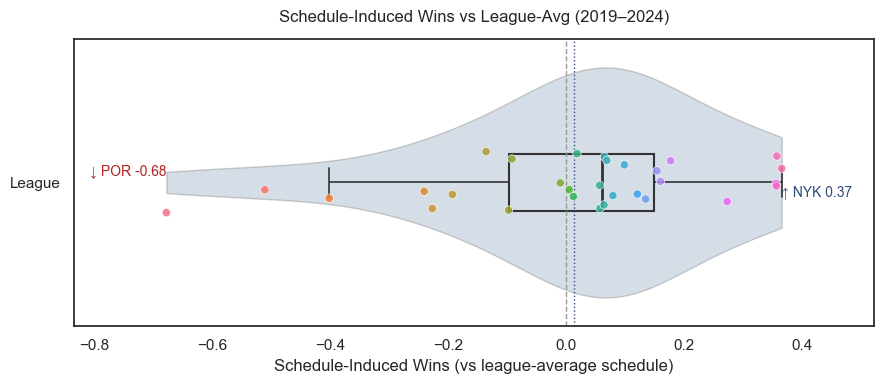

In [13]:
# Horizontal violin + transparent boxplot + team scatter.
# Expects columns: ['team','schedule_wins'].
def plot_schedule_wins_violin(team_impacts: pd.DataFrame,
                              title="Schedule-Induced Wins vs League-Avg (2019–2024)"):
    df = team_impacts.copy()
    # single-category to plot one violin
    df["league"] = "League"

    plt.figure(figsize=(9, 4))
    ax = plt.gca()

    # 1) Violin plot
    sns.violinplot(
        data=df,
        x="schedule_wins",
        y="league",
        inner=None,         # no internal bars
        cut=0,              # don't extend beyond data range
        linewidth=1,
        color="#4C78A8",    # nice blue
        alpha=0.25,         # translucent fill
        ax=ax
    )

    # 2) Transparent boxplot overlay
    sns.boxplot(
        data=df,
        x="schedule_wins",
        y="league",
        width=0.2,
        showcaps=True,
        showfliers=False,
        boxprops=dict(facecolor="none", edgecolor="#333333", linewidth=1.5),
        whiskerprops=dict(color="#333333", linewidth=1.2),
        capprops=dict(color="#333333", linewidth=1.2),
        medianprops=dict(color="#333333", linewidth=2),
        ax=ax
    )

    # 3) Scatter/strip of team points (jittered vertically so they don't overlap)
    sns.stripplot(
        data=df,
        x="schedule_wins",
        y="league",
        hue="team",
        dodge=False,
        jitter=0.12,
        alpha=0.85,
        size=6,
        edgecolor="white",
        linewidth=0.5,
        legend=False,
        ax=ax
    )

    # Reference lines and annotations
    mean_val = df["schedule_wins"].mean()
    ax.axvline(0.0, color="#999", linestyle="--", linewidth=1, label="Zero (league avg baseline)")
    ax.axvline(mean_val, color="#2F4B7C", linestyle=":", linewidth=1, label=f"Mean: {mean_val:.2f}")

    # Tidy labels
    ax.set_title(title, pad=12)
    ax.set_xlabel("Schedule-Induced Wins (vs league-average schedule)")
    ax.set_ylabel("")  # single category row
    
    # x-limits with padding
    lo, hi = df["schedule_wins"].min(), df["schedule_wins"].max()
    span = hi - lo if hi > lo else 1.0
    ax.set_xlim(lo - 0.15*span, hi + 0.15*span)

    # annotate extremes
    top = df.nlargest(1, "schedule_wins").iloc[0]
    bot = df.nsmallest(1, "schedule_wins").iloc[0]
    ax.text(top["schedule_wins"], 0.06, f"↑ {top['team']} {top['schedule_wins']:.2f}",
            ha="left", va="bottom", fontsize=10, color="#2F4B7C")
    ax.text(bot["schedule_wins"], -0.06, f"↓ {bot['team']} {bot['schedule_wins']:.2f}",
            ha="right", va="top", fontsize=10, color="#B22222")

    plt.tight_layout()
    plt.show()

plot_schedule_wins_violin(team_impacts)


In [14]:
def make_rank_table(team_impacts: pd.DataFrame, decimals=2):

    df = (team_impacts
          .copy()
          .sort_values("schedule_wins", ascending=False, ignore_index=True))

    df.insert(0, "Rank", np.arange(1, len(df)+1))
    df.rename(columns={"team": "Team", "schedule_wins": "Wins"}, inplace=True)
    df["Wins"] = df["Wins"].round(decimals)

    # Transpose 
    df_t = df.set_index("Team")[["Wins"]].T 

    styled = (
        df_t.style
        .format({team: f"{{:.{decimals}f}}" for team in df["Team"]})
        .background_gradient(axis=1, cmap="RdYlGn")  # color per team across row
        .set_caption("Schedule-Induced Wins vs League-Average Schedule (2019–2024)")
        .set_properties(**{"text-align": "center"})
    )

    return styled

# Display table
make_rank_table(team_impacts)


Team,NYK,IND,PHI,LAL,MIL,HOU,CHA,DET,WAS,UTA,OKC,NOP,MEM,TOR,DEN,BKN,CLE,SAS,MIN,BOS,ATL,DAL,CHI,MIA,ORL,PHX,LAC,GSW,SAC,POR
Wins,0.37,0.36,0.36,0.36,0.27,0.18,0.16,0.15,0.14,0.12,0.10,0.08,0.07,0.07,0.06,0.06,0.06,0.02,0.01,0.01,-0.01,-0.09,-0.10,-0.14,-0.19,-0.23,-0.24,-0.40,-0.51,-0.68


- Most Helped by Schedule: NYK (+0.37 wins)     
- Most Hurt by Schedule: POR (-0.68 wins)    
